# FLUJO 3 — Resultados PSBP-FD (evaluación fuera de muestra)

**Escenario 2 — FGARCH(1,1) funcional** (Algoritmo 2 del anexo).
Consume los artefactos que produjo `06_01_simulaciones.ipynb`; el flujo de evaluación es
idéntico al del resto de escenarios, de modo que las métricas son comparables
entre ellos.

1. Carga de artefactos vía el contrato de `pipelines.artifacts`.
2. Lectura de trazas MATLAB (entrenadas sobre el bloque de entrenamiento).
3. Diagnósticos de convergencia MCMC.
4. **Evaluación fuera de muestra** sobre el bloque de prueba $\{T_0+1,\dots,T\}$
   (§2.2.3.1), a horizonte $h=1$, con media y bandas de credibilidad.

Las trazas provienen de entrenar el muestreador con `dataset_fpc_*_train.csv`;
la evaluación se realiza sobre `dataset_fpc_*_test.csv`, cuyos predictores
rezagados se condicionan en la historia observada. La verificación del
predictor contra la salida de MATLAB (`inEout`) se hace sobre el bloque de
entrenamiento, que es donde `inEout` está definido.

> Bajo el Escenario 2 la media condicional es constante: la dinámica vive en la varianza condicional. En consecuencia, el $R^2$ sobre los scores puede ser bajo **sin que ello indique un fallo del modelo**, y las métricas informativas son las distribucionales — CRPS, cobertura, PIT y puntaje de energía (§5.6–5.7).


## 1. Imports y rutas

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import sys
from pathlib import Path
from scipy.io import loadmat

# ── Contrato de artefactos y utilidades (pipelines / utils) ──────────────────
from model_psbp_fd.pipelines import (
    cargar_curvas, cargar_representacion, cargar_fpca,
    cargar_estandarizador, cargar_datasets_ar, cargar_hiperparametros,
    cargar_config_evaluacion,
)
from model_psbp_fd.functions_models import DataStandardizer, FunctionalRepresentation
from model_psbp_fd.utils import get_project_root

# ── Inferencia predictiva del modelo (v3) ────────────────────────────────────
# La v2 reportaba, bajo return_std=True, la desviación POSTERIOR DE LA MEDIA
# condicional; usarla como banda produce intervalos sistemáticamente angostos.
# La v3 devuelve la desviación PREDICTIVA (ley de varianza total) y además
# permite MUESTREAR la predictiva, sin lo cual CRPS, PIT y puntaje de energía
# sólo pueden calcularse bajo la aproximación gaussiana de dos momentos, que
# descarta la multimodalidad y la asimetría que el modelo existe para capturar.
from model_psbp_fd.models.pspb_fd_v3 import (
    PSBPPredictor, PropagadorFuncional, residuos_representacion,
    bandas_puntuales,
)

# ── Métricas de evaluación (fit) ─────────────────────────────────────────────
from model_psbp_fd.fit import (
    rmse_por_coeficiente, r2_por_columna, razon_dispersion,
    mise, rmse_funcional, cobertura, intervalo_muestral,
    crps_muestral, pit_muestral, diagnostico_pit, agrupar_momentos,
    energy_score,
)

# ── Visualización ────────────────────────────────────────────────────────────
from model_psbp_fd.graphics import (
    plot_global_components, plot_active_clusters,
    plot_convergence_bj, plot_convergence_pj,
    plot_scatter_theta, plot_functional_comparison, plot_fts_comparison,
)

plt.style.use("seaborn-v0_8-darkgrid")
%matplotlib inline

In [3]:
# ── Raíz del proyecto ─────────────────────────────────────────────────────
PROJECT_ROOT = get_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print(f"PROJECT_ROOT : {PROJECT_ROOT}")

# ── Identificación del experimento ───────────────────────────────────────
# Debe coincidir EXACTAMENTE con la celda §1.1 de 06_01_simulaciones.ipynb: es el mismo
# EXPERIMENT_ID el que nombra las rutas de artefactos, trazas y reportes.
#   ESCENARIO_ID : escenario/experimento (Algoritmo k del anexo)
#   REPLICA_ID   : replica Monte Carlo de la trayectoria simulada (eje futuro)
BASENAME      = "modelo_experimento_1"
ESCENARIO_ID  = 2                          # Algoritmo 2 del anexo (FGARCH(1,1))
REPLICA_ID    = 1
EXPERIMENT_ID = f"{BASENAME}_{ESCENARIO_ID}"
print(f"Experiment ID : {EXPERIMENT_ID}")
print(f"Escenario     : {ESCENARIO_ID}   Replica : {REPLICA_ID}")
# La semilla se lee de hyperparameters.json (§2): única fuente de verdad.

PROJECT_ROOT : C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1
Experiment ID : modelo_experimento_1_2
Escenario     : 2   Replica : 1


In [4]:
# ── Construcción de rutas ─────────────────────────────────────────────────
_REPORT_DIR   = PROJECT_ROOT / "reports"   / "simulaciones" / EXPERIMENT_ID
_ARTEFACT_DIR = PROJECT_ROOT / "artefact"  / "simulaciones" / EXPERIMENT_ID

PATHS = {
    "raw":          PROJECT_ROOT / "data" / "simulaciones" / "raw"       / EXPERIMENT_ID,
    "functional":   PROJECT_ROOT / "data" / "simulaciones" / "processed" / "functional" / EXPERIMENT_ID,
    "predict":      PROJECT_ROOT / "data" / "simulaciones" / "processed" / "predict"    / EXPERIMENT_ID,
    "out_report":   _REPORT_DIR,
    "out_artefact": _ARTEFACT_DIR,
}
for name, path in PATHS.items():
    path.mkdir(parents=True, exist_ok=True)
    print(f"  {name:12s} → {path}")

  raw          → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\modelo_experimento_1_2
  functional   → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\processed\functional\modelo_experimento_1_2
  predict      → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\processed\predict\modelo_experimento_1_2
  out_report   → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\simulaciones\modelo_experimento_1_2
  out_artefact → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\artefact\simulaciones\modelo_experimento_1_2


## 2. Carga de artefactos (contrato `pipelines.artifacts`)

Todo lo que el flujo de preprocesamiento persistió se recupera por sus
funciones `cargar_*` emparejadas: datasets de entrenamiento y prueba, FPCA,
estandarizador, curvas, hiperparámetros y configuración de evaluación. Las
matrices FPCA quedan garantizadas en dos dimensiones aunque $M=1$.

In [5]:
# ── Datasets AR(p): bloques de entrenamiento y prueba ────────────────────────
dfs_train, manifest = cargar_datasets_ar(PATHS, bloque="train")
dfs_test,  _        = cargar_datasets_ar(PATHS, bloque="test")

n_lags        = manifest["n_lags"]
COMPONENT_IDX = manifest["component_idx"]      # lista base-0
n_components  = len(COMPONENT_IDX)
cov_names     = manifest["cov_names"]
scores_scale  = manifest["scores_scale"]

# Partición temporal (§2.2.3.1)
T   = int(manifest["T"])
T0  = int(manifest["T0"])
n_test_eff = int(manifest.get("n_test_eff", T - T0))

assert scores_scale == "standardized_zscore_ddof0", (
    f"scores_scale={scores_scale!r}: los datasets no usan scores estandarizados."
)

print(f"n_components : {n_components}   n_lags : {n_lags}")
print(f"COMPONENT_IDX: {COMPONENT_IDX}")
print(f"Partición    : T={T}, T0={T0}, test={n_test_eff}")
for k in range(n_components):
    print(f"  FPC {COMPONENT_IDX[k]+1}: train {dfs_train[k].shape}, test {dfs_test[k].shape}")

n_components : 4   n_lags : 3
COMPONENT_IDX: [0, 1, 2, 3]
Partición    : T=200, T0=160, test=40
  FPC 1: train (157, 13), test (40, 13)
  FPC 2: train (157, 13), test (40, 13)
  FPC 3: train (157, 13), test (40, 13)
  FPC 4: train (157, 13), test (40, 13)


In [6]:
# ── Hiperparámetros y contrato Python ↔ MATLAB ───────────────────────────
hp_json = cargar_hiperparametros(PATHS)          # verifica claves del contrato

N_ITER    = int(hp_json["n_iter"])               # cadenas por componente
SEED_BASE = int(hp_json["seed_base"])
MCMC_CFG  = hp_json["mcmc_config"]

assert hp_json["scores_scale"] == scores_scale, "scores_scale discrepa manifest↔hp."
assert len(hp_json["hyperparams_list"]) == n_components, (
    f"n_components discrepa: manifest={n_components}, hp={len(hp_json['hyperparams_list'])}."
)

# Configuración de evaluación (§2.2.3)
eval_config = cargar_config_evaluacion(PATHS)

print(f"N_ITER      : {N_ITER}  (cadenas por componente)")
print(f"SEED_BASE   : {SEED_BASE}  · esquema: {hp_json.get('seed_scheme')}")
print(f"MCMC config : {MCMC_CFG}")
print(f"eval scheme : {eval_config.get('scheme')}  horizontes={eval_config.get('horizons')}")

N_ITER      : 3  (cadenas por componente)
SEED_BASE   : 41232  · esquema: SEED_BASE + chain*9973 + k*31
MCMC config : {'nsim': 2000, 'burn': 500, 'N': 20, 'M': 50}
eval scheme : holdout_temporal  horizontes=[1]


In [7]:
# ── FPCA, estandarizador y curvas (contrato de artefactos) ───────────────────
fpca = cargar_fpca(PATHS)                 # ArtefactosFPCA: reconstruct / scores_a_theta
_ver = fpca.verificar()
print(f"FPCA: M={fpca.M}, K={fpca.K}  ·  verificación {_ver}")
assert _ver["todo_ok"], "Las identidades FPCA no se cumplen en los artefactos cargados."

scores_standardizer = cargar_estandarizador(PATHS, DataStandardizer)
X_curves, domain_grid = cargar_curvas(PATHS)
print(f"X_curves {X_curves.shape}  ·  grilla {domain_grid.shape}")

# Representación funcional B-spline (para las comparativas de curva)
fr, THETA, fr_cfg = cargar_representacion(PATHS, estricto=False)
fpca_available = True
print(f"FunctionalRepresentation: {'cargada' if fr is not None else 'ausente'}"
      + (f" (K={fr.n_basis})" if fr is not None else ""))

# Atajos a los objetos FPCA (escala original de los scores)
Psi_grid = fpca.Psi_grid          # (G, M)
mu_grid  = fpca.mu_grid           # (G,)
Phi      = fpca.Phi               # (G, K)
M_fpca   = fpca.M
SCORES   = fpca.SCORES            # (T, M) escala original
# Scores estandarizados de toda la serie, reconstruidos con el estandarizador
SCORES_STD = scores_standardizer.transform(SCORES)

FPCA: M=4, K=7  ·  verificación {'err_ortonormalidad_gram': 2.886579864025407e-15, 'err_rutas_reconstruccion': 1.7763568394002505e-15, 'todo_ok': True}
X_curves (200, 70)  ·  grilla (70,)
FunctionalRepresentation: cargada (K=7)


## 3. Lectura de trazas MATLAB

Las trazas se generan entrenando el muestreador con el bloque de
entrenamiento. El nombre de archivo y el esquema de semillas coinciden con
`psbp_fd_iteracion.m`.

In [8]:
# ── Configuración de trazas ───────────────────────────────────────────────
TRACE_DIR = PATHS["out_artefact"]

def trace_path(fpc_idx: int, tt: int) -> Path:
    return TRACE_DIR / f"chain_fpc_{fpc_idx}_iter{tt:02d}.mat"

print(f"TRACE_DIR : {TRACE_DIR}")
print(f"N_ITER    : {N_ITER}  (cadenas por componente)")
print(f"Ejemplo   : {trace_path(COMPONENT_IDX[0]+1, 1).name}")

TRACE_DIR : C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\artefact\simulaciones\modelo_experimento_1_2
N_ITER    : 3  (cadenas por componente)
Ejemplo   : chain_fpc_1_iter01.mat


In [9]:
# ── Loader: .mat → dict de trazas ────────────────────────────────────────
def load_trace_mat(path: Path) -> tuple:
    """Carga un .mat de psbp_train → (traces, burn, feature_names)."""
    m = loadmat(str(path))
    keys2d = ["betajhout", "beta0hout", "tauhout", "alphahout",
              "psijhout", "Gammajhout", "gammajhout", "pijout",
              "wjout", "osumout", "inEout"]
    traces = {k: np.asarray(m[k], dtype=np.float64) for k in keys2d}
    for k in ["muout", "N1out", "Nout"]:
        traces[k] = np.asarray(m[k], dtype=np.float64).ravel()
    burn = int(np.asarray(m["burn"]).ravel()[0])
    feat = str(np.atleast_1d(m["feature_names"]).ravel()[0]).split(",")
    return traces, burn, feat


class MatlabTraceModel:
    """
    Adaptador: trazas MATLAB → interfaz de las funciones plot_* y del predictor v3.

    Se conserva `load_trace_mat` en lugar de `cargar_trazas_mat` de la v3 porque
    aquel lee además `burn` y `feature_names` del propio .mat, que es lo que
    permite verificar el contrato de covariables contra el dataset.
    """
    def __init__(self, traces: dict, burn: int, feature_names: list):
        self.traces         = traces
        self.feature_names_ = list(feature_names)
        self.burn           = int(burn)
        self.n_features_    = int(traces["betajhout"].shape[2])
        self.predictor_     = PSBPPredictor(traces=traces, burn=burn)

    def _design(self, df: pd.DataFrame) -> np.ndarray:
        Xp = np.asarray(df.iloc[:, 1:], dtype=float)
        return np.hstack([np.ones((Xp.shape[0], 1)), Xp])

    # ── Momentos: `sd` es ahora la desviación PREDICTIVA ──────────────────
    def momentos(self, df: pd.DataFrame) -> dict:
        return self.predictor_.momentos_predictivos(self._design(df))

    def predict(self, df: pd.DataFrame, return_std: bool = False):
        return self.predictor_.predict(self._design(df), return_std=return_std)

    # ── Extracciones de la distribución predictiva, forma (S, n) ──────────
    def muestrear(self, df: pd.DataFrame, d: int = 1, seed=None) -> np.ndarray:
        return self.predictor_.muestrear(self._design(df), d, seed=seed)

    def inclusion_probs(self, as_series: bool = False):
        incl = self.predictor_.probabilidades_inclusion()
        if incl is None:
            incl = np.full(self.n_features_, np.nan)
        if as_series:
            return pd.Series(incl, index=self.feature_names_, name="inclusion_prob")
        return incl

    def rmse(self, df: pd.DataFrame, y_obs=None) -> float:
        if y_obs is None:
            y_obs = np.asarray(df.iloc[:, 0], dtype=float)
        return float(np.sqrt(np.mean((y_obs - self.predict(df)) ** 2)))

In [10]:
# ── Ensamblar models_chains[k][c] ────────────────────────────────────────
# El feature_names del .mat se verifica contra las columnas del dataset de
# ENTRENAMIENTO (con el que se entrenó). Como train y test comparten cov_names,
# el mismo predictor se aplica luego al bloque de prueba.
missing = [trace_path(COMPONENT_IDX[k]+1, c+1).name
           for k in range(n_components) for c in range(N_ITER)
           if not trace_path(COMPONENT_IDX[k]+1, c+1).exists()]
assert not missing, (
    f"Faltan {len(missing)} trazas en {TRACE_DIR}: {missing}. "
    "Ejecuta psbp_fd_iteracion.m antes de continuar."
)

models_chains = {k: {} for k in range(n_components)}
_meta_seen = set()

for k in range(n_components):
    fpc_idx = COMPONENT_IDX[k] + 1
    expected = list(dfs_train[k].columns[1:])
    for c in range(N_ITER):
        traces, burn, feat = load_trace_mat(trace_path(fpc_idx, c + 1))
        assert feat == expected, (
            f"[k={k} tt={c+1}] feature_names del .mat ≠ columnas del dataset train:\n"
            f"  mat={feat}\n  dfs_train={expected}"
        )
        models_chains[k][c] = MatlabTraceModel(traces, burn, feat)
        _meta_seen.add((traces["betajhout"].shape[0], traces["betajhout"].shape[1], burn))
        print(f"  FPC {fpc_idx}  iter{c+1:02d}  (p={len(feat)}, "
              f"N={traces['betajhout'].shape[1]}, nsim={traces['betajhout'].shape[0]}, burn={burn})")

assert len(_meta_seen) == 1, f"Configuraciones MCMC heterogéneas entre trazas: {_meta_seen}."
nsim, N, BURN = next(iter(_meta_seen))
n_chains_loaded = N_ITER

assert (nsim, N, BURN) == (MCMC_CFG["nsim"], MCMC_CFG["N"], MCMC_CFG["burn"]), (
    f"Trazas (nsim={nsim}, N={N}, burn={BURN}) ≠ hyperparameters.json ({MCMC_CFG})."
)
print(f"\n✓ models_chains: {n_components} componente(s) × {n_chains_loaded} cadena(s)  BURN={BURN}")

  FPC 1  iter01  (p=12, N=20, nsim=2000, burn=500)
  FPC 1  iter02  (p=12, N=20, nsim=2000, burn=500)
  FPC 1  iter03  (p=12, N=20, nsim=2000, burn=500)
  FPC 2  iter01  (p=12, N=20, nsim=2000, burn=500)
  FPC 2  iter02  (p=12, N=20, nsim=2000, burn=500)
  FPC 2  iter03  (p=12, N=20, nsim=2000, burn=500)
  FPC 3  iter01  (p=12, N=20, nsim=2000, burn=500)
  FPC 3  iter02  (p=12, N=20, nsim=2000, burn=500)
  FPC 3  iter03  (p=12, N=20, nsim=2000, burn=500)
  FPC 4  iter01  (p=12, N=20, nsim=2000, burn=500)
  FPC 4  iter02  (p=12, N=20, nsim=2000, burn=500)
  FPC 4  iter03  (p=12, N=20, nsim=2000, burn=500)

✓ models_chains: 4 componente(s) × 3 cadena(s)  BURN=500


## 4. Diagnósticos de convergencia MCMC

| Estadístico | Referencia | Lectura |
|---|---|---|
| ACF(lag) | autocorrelación residual | cerca de 0 ⇒ buena mezcla |
| ESS | Geyer (1992) | ESS ≳ 400 ideal |
| Geweke z | test z entre segmentos | \|z\| < 2 ⇒ no rechazo |
| Gelman-Rubin R̂ | Brooks-Gelman (1998) | R̂ < 1.1 ⇒ convergencia |

### 4.1 Componentes globales y clústeres activos

In [ ]:
for k in models_chains:
    fig = plot_global_components(
        models_chains, k, BURN, n_chains_loaded, title_prefix=f"FPC {COMPONENT_IDX[k]+1}",
        save_path=str(PATHS["out_report"] / f"10_global_comp_k{COMPONENT_IDX[k]+1}.png"))
    plt.show()

In [ ]:
for k in models_chains:
    fig = plot_active_clusters(
        models_chains, k, BURN, n_chains_loaded, title_prefix=f"FPC {COMPONENT_IDX[k]+1}",
        save_path=str(PATHS["out_report"] / f"11_clusters_activos_k{COMPONENT_IDX[k]+1}.png"))
    plt.show()

### 4.2 Convergencia completa (traza | ACF | posterior + métricas)

In [ ]:
all_diag_bj = {}
for k in models_chains:
    feat = models_chains[k][0].feature_names_
    fig, diag = plot_convergence_bj(
        models_chains, k, BURN, n_chains_loaded, feature_names=feat,
        title_prefix=f"FPC {COMPONENT_IDX[k]+1}",
        save_path=str(PATHS["out_report"] / f"12_convergencia_bj_k{COMPONENT_IDX[k]+1}.png"))
    all_diag_bj[k] = diag
    plt.show()

In [ ]:
all_diag_pj = {}
for k in models_chains:
    feat = models_chains[k][0].feature_names_
    fig, diag = plot_convergence_pj(
        models_chains, k, BURN, n_chains_loaded, feature_names=feat,
        title_prefix=f"FPC {COMPONENT_IDX[k]+1}",
        save_path=str(PATHS["out_report"] / f"13_convergencia_pj_k{COMPONENT_IDX[k]+1}.png"))
    all_diag_pj[k] = diag
    plt.show()

In [ ]:
# ── Tabla resumen de diagnósticos + persistencia ─────────────────────────
diag_records = []
for k in models_chains:
    for rec in all_diag_bj.get(k, []):
        diag_records.append({"componente": COMPONENT_IDX[k]+1, "param": "beta_j", **rec})
    for rec in all_diag_pj.get(k, []):
        diag_records.append({"componente": COMPONENT_IDX[k]+1, "param": "p_j", **rec})

diag_df = pd.DataFrame(diag_records)
if not diag_df.empty:
    diag_df.to_csv(PATHS["out_report"] / "30_diagnosticos_mcmc.csv", index=False)
    print(f"[out_report] 30_diagnosticos_mcmc.csv  ({len(diag_df)} filas)")
    display(diag_df.style
        .format({"ess_min": "{:.1f}", "ess_mean": "{:.1f}",
                 "geweke_max": "{:+.2f}", "rhat": "{:.3f}"})
        .background_gradient(subset=["rhat"], cmap="RdYlGn_r", vmin=1.0, vmax=1.2)
        .background_gradient(subset=["ess_min"], cmap="RdYlGn", vmin=0, vmax=500)
        .set_caption("Diagnósticos MCMC por variable"))
else:
    print("No hay datos de diagnóstico disponibles.")

## 5. Evaluación fuera de muestra (bloque de prueba, $h=1$)

Las predicciones se calculan sobre los predictores del bloque de prueba
(`dataset_fpc_*_test.csv`), cuya respuesta corresponde a $t\in\{T_0+1,\dots,T\}$
y cuyos rezagos se condicionan en la historia observada. Todo está en escala de
**scores estandarizados**; la reconstrucción de curvas (§5.3–5.4) des-estandariza
con el `scores_standardizer` y usa los operadores de la FPCA cargada.

Antes de evaluar se verifica que el predictor reproduce la salida in-sample de
MATLAB (`inEout`) sobre el **bloque de entrenamiento**, que es donde `inEout`
está definido. Las bandas $\mu\pm1.96\sigma$ son la aproximación de dos momentos;
CRPS y PIT (§5.6) usan la predictiva muestral completa.

In [11]:
# ── Verificación del predictor contra MATLAB (inEout, sobre ENTRENAMIENTO) ──
# inEout es E[y|x] in-sample por iteración calculado por MATLAB sobre el bloque
# de entrenamiento. Su media post burn-in debe coincidir con la predicción del
# PSBPPredictor evaluado en los mismos predictores de entrenamiento.
# NOTA sobre por qué la diferencia nunca es exactamente cero: en psbp_train.m
# `inE` se calcula ANTES de actualizar betajh/beta0h dentro de la misma
# iteración, mientras que las trazas de parámetros se registran DESPUÉS. Por
# tanto inEout[t] corresponde a θ^(t-1) y betajhout[t] a θ^(t). El promedio
# posterior difiere entonces sólo en los términos de borde, de orden 1/n_post.
# No invalida nada y no debe perseguirse como si fuera un defecto: lo que se
# vigila es la correlación.
print("Verificación predictor ↔ inEout (bloque de entrenamiento):")
for k in models_chains:
    for c in sorted(models_chains[k]):
        m_c = models_chains[k][c]
        mu_tr = m_c.predict(dfs_train[k], return_std=False)
        inE   = m_c.traces["inEout"][m_c.burn:].mean(axis=0)
        diff  = float(np.abs(inE - mu_tr).max())
        corr  = float(np.corrcoef(inE, mu_tr)[0, 1])
        flag  = "" if corr > 0.999 else "  ⚠ revisar contrato sampler↔predictor"
        print(f"  FPC {COMPONENT_IDX[k]+1} cad{c+1}: |inEout−predict|max={diff:.4f} "
              f"corr={corr:.5f}{flag}")

Verificación predictor ↔ inEout (bloque de entrenamiento):
  FPC 1 cad1: |inEout−predict|max=0.0005 corr=0.99999
  FPC 1 cad2: |inEout−predict|max=0.0001 corr=1.00000
  FPC 1 cad3: |inEout−predict|max=0.0001 corr=1.00000
  FPC 2 cad1: |inEout−predict|max=0.0001 corr=1.00000
  FPC 2 cad2: |inEout−predict|max=0.0000 corr=1.00000
  FPC 2 cad3: |inEout−predict|max=0.0004 corr=1.00000
  FPC 3 cad1: |inEout−predict|max=0.0000 corr=1.00000
  FPC 3 cad2: |inEout−predict|max=0.0000 corr=1.00000
  FPC 3 cad3: |inEout−predict|max=0.0002 corr=1.00000
  FPC 4 cad1: |inEout−predict|max=0.0002 corr=1.00000
  FPC 4 cad2: |inEout−predict|max=0.0001 corr=1.00000
  FPC 4 cad3: |inEout−predict|max=0.0001 corr=1.00000


In [12]:
# ── Predicciones FUERA DE MUESTRA por componente ────────────────────────────
# Dos cambios respecto de la versión anterior:
#
# 1. `sd` es ahora la desviación PREDICTIVA completa,
#        Var[y|x] = E_t[Var(y|x,θ_t)] + Var_t[E(y|x,θ_t)],
#    y no sólo el segundo término. Se reporta también `sd_centro` (el término
#    que devolvía la v2) para dimensionar la diferencia: su cociente indica
#    cuánto se estrechaban las bandas anteriores.
#
# 2. Los intervalos y las métricas distribucionales se calculan sobre
#    EXTRACCIONES de la predictiva y no sobre ±1.96σ. La predictiva del PSBPM
#    es una mezcla: imponerle simetría y unimodalidad anula justamente la
#    propiedad que el modelo busca demostrar.
#
# Las cadenas se agrupan con la ley de varianza total para los momentos
# (fit.agrupar_momentos) y por concatenación para las muestras, que es la
# mezcla de igual peso.

S_POR_ITER = 1          # extracciones por iteración posterior
NIVEL      = 0.95
SEED_PRED  = 20260725

eval_results = {}

for k in models_chains:
    y_obs     = np.asarray(dfs_test[k].iloc[:, 0], dtype=float)
    chain_ids = sorted(models_chains[k].keys())

    _means, _stds, _centros, _draws = [], [], [], []
    for c in chain_ids:
        mom = models_chains[k][c].momentos(dfs_test[k])
        _means.append(mom["media"])
        _stds.append(mom["sd"])                 # PREDICTIVA
        _centros.append(mom["sd_centro"])       # lo que reportaba la v2
        _draws.append(models_chains[k][c].muestrear(
            dfs_test[k], S_POR_ITER, seed=SEED_PRED + 1000 * k + c))

    y_hat_chains = np.column_stack(_means)                    # (n_test, n_chains)
    y_std_chains = np.column_stack(_stds)
    y_hat, y_std = agrupar_momentos(y_hat_chains, y_std_chains)
    sd_centro    = np.column_stack(_centros).mean(axis=1)

    draws = np.concatenate(_draws, axis=0)                    # (S, n_test)

    # ── Intervalo muestral: respeta asimetría y multimodalidad ──────────────
    li, ls = intervalo_muestral(draws, nivel=NIVEL)
    cob    = cobertura(y_obs, li, ls)

    # ── Reglas de puntuación propias sobre la predictiva muestral ───────────
    crps_k = float(crps_muestral(y_obs, draws).mean())
    pit_k  = pit_muestral(y_obs, draws)
    diag_k = diagnostico_pit(pit_k, n_bins=min(10, max(4, len(y_obs) // 3)))

    incl_named = pd.concat(
        [models_chains[k][c].inclusion_probs(as_series=True) for c in chain_ids],
        axis=1).mean(axis=1).rename("inclusion_prob")

    eval_results[k] = {
        "y_obs": y_obs, "y_hat": y_hat, "y_std": y_std,
        "sd_centro": sd_centro, "y_hat_chains": y_hat_chains,
        "draws": draws, "li": li, "ls": ls,
        "incl_named": incl_named,
        "rmse":  float(rmse_por_coeficiente(y_obs[:, None], y_hat[:, None])[0]),
        "cov95": cob["cobertura"], "ancho95": cob["ancho_medio"],
        "crps":  crps_k, "pit": pit_k, "pit_diag": diag_k,
    }

    _razon = float(np.mean(y_std / np.clip(sd_centro, 1e-12, None)))
    print(f"  FPC {COMPONENT_IDX[k]+1}  RMSE={eval_results[k]['rmse']:.4f}  "
          f"Cob{int(NIVEL*100)}={cob['cobertura']:.3f}  ancho={cob['ancho_medio']:.3f}  "
          f"CRPS={crps_k:.4f}  PIT={diag_k['forma']}")
    print(f"           sd predictiva / sd_centro (v2) = {_razon:.2f}×   "
          f"→ las bandas de la v2 eran ese factor más angostas")

_S = eval_results[0]["draws"].shape[0]
print(f"\n✓ eval_results sobre {n_test_eff} orígenes de prueba  "
      f"({_S} extracciones = {n_chains_loaded} cadenas × {(nsim-BURN)} iter × {S_POR_ITER})")

  FPC 1  RMSE=0.8660  Cob95=0.975  ancho=4.017  CRPS=0.4790  PIT=aproximadamente uniforme
           sd predictiva / sd_centro (v2) = 10.94×   → las bandas de la v2 eran ese factor más angostas
  FPC 2  RMSE=1.0191  Cob95=0.950  ancho=4.006  CRPS=0.5618  PIT=aproximadamente uniforme
           sd predictiva / sd_centro (v2) = 10.45×   → las bandas de la v2 eran ese factor más angostas
  FPC 3  RMSE=0.9275  Cob95=0.950  ancho=3.891  CRPS=0.5201  PIT=aproximadamente uniforme
           sd predictiva / sd_centro (v2) = 10.95×   → las bandas de la v2 eran ese factor más angostas
  FPC 4  RMSE=1.1657  Cob95=0.875  ancho=3.957  CRPS=0.6628  PIT=aproximadamente uniforme
           sd predictiva / sd_centro (v2) = 9.86×   → las bandas de la v2 eran ese factor más angostas

✓ eval_results sobre 40 orígenes de prueba  (4500 extracciones = 3 cadenas × 1500 iter × 1)


### 5.1 Scatter ξ observado vs ξ predicho (test, scores estandarizados)

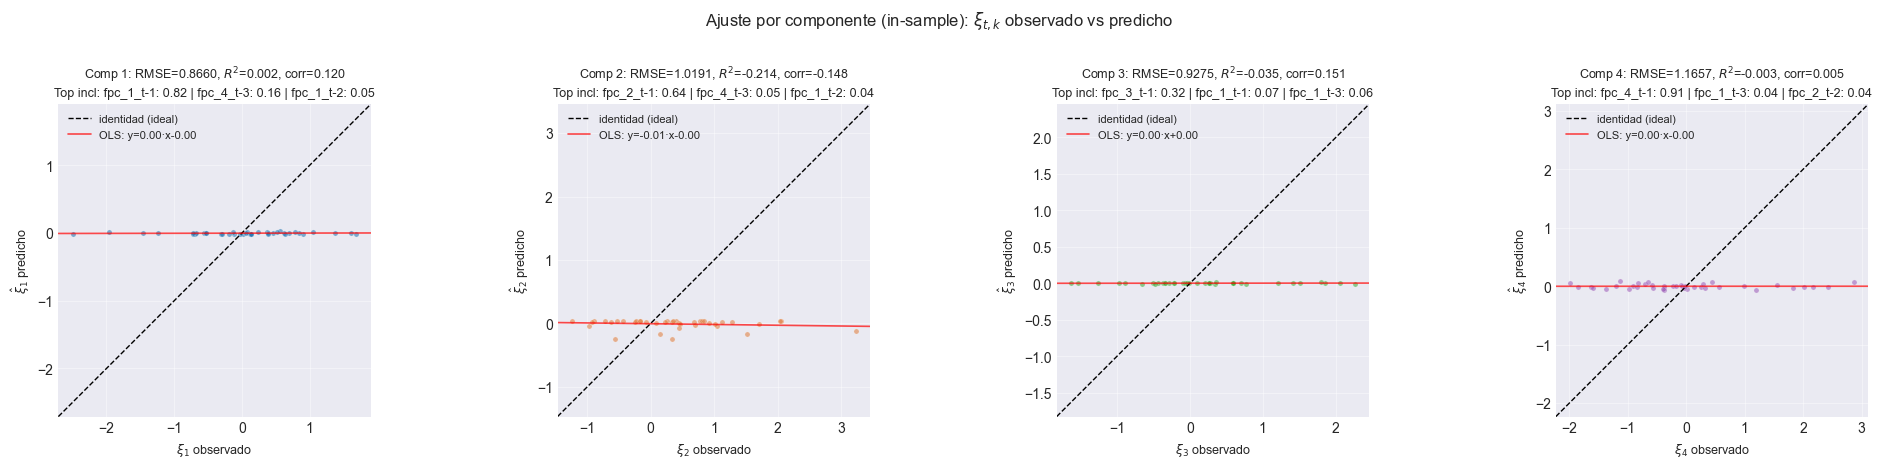

In [13]:
fig = plot_scatter_theta(
    eval_results, n_components=len(models_chains),
    save_path=str(PATHS["out_report"] / "20_scatter_scores.png"))
plt.show()

### 5.2 Probabilidades de inclusión por variable

In [14]:
incl_df = pd.DataFrame({f"FPC {COMPONENT_IDX[k]+1}": eval_results[k]["incl_named"]
                        for k in models_chains})
display(incl_df.style.background_gradient(cmap="RdYlGn", vmin=0, vmax=1).format("{:.3f}")
        .set_caption("P(γ_j = 1 | data) — Probabilidades de inclusión por variable"))

,FPC 1,FPC 2,FPC 3,FPC 4
fpc_1_lag1,0.824,0.039,0.067,0.041
fpc_2_lag1,0.036,0.640,0.037,0.028
fpc_3_lag1,0.037,0.035,0.317,0.032
fpc_4_lag1,0.038,0.027,0.048,0.911
fpc_1_lag2,0.046,0.040,0.040,0.024
fpc_2_lag2,0.037,0.040,0.036,0.042
fpc_3_lag2,0.026,0.028,0.048,0.035
fpc_4_lag2,0.032,0.024,0.038,0.032
fpc_1_lag3,0.025,0.033,0.064,0.042
fpc_2_lag3,0.033,0.029,0.044,0.039


### 5.3 Reconstrucción funcional (bloque de prueba)

Las predicciones de scores (estandarizadas) se des-estandarizan y se
reconstruyen curvas con los operadores de la FPCA cargada
(`fpca.reconstruct` y `fpca.scores_a_theta`), que garantizan la equivalencia
de las dos rutas por ortonormalidad L². La comparación es contra `X_curves`
en el bloque de prueba, $t\in\{T_0+1,\dots,T\}$.

[sanidad] max|ruta B-spline − ruta FPCA| : 1.78e-15  (≈ 0)
RMSE funcional (truncamiento FPCA) : 0.502030
MISE predicción (test)             : 1.114389
RMSE funcional predicción (test)   : 1.055646
── Métricas de reconstrucción (escala de X_true) ──
  RMSE representación : 0.505075   NRMSE=0.308
  RMSE modelo         : 0.927636   NRMSE=0.565
  RMSE total          : 1.056504   NRMSE=0.643
  Ratio modelo/total  : 0.878


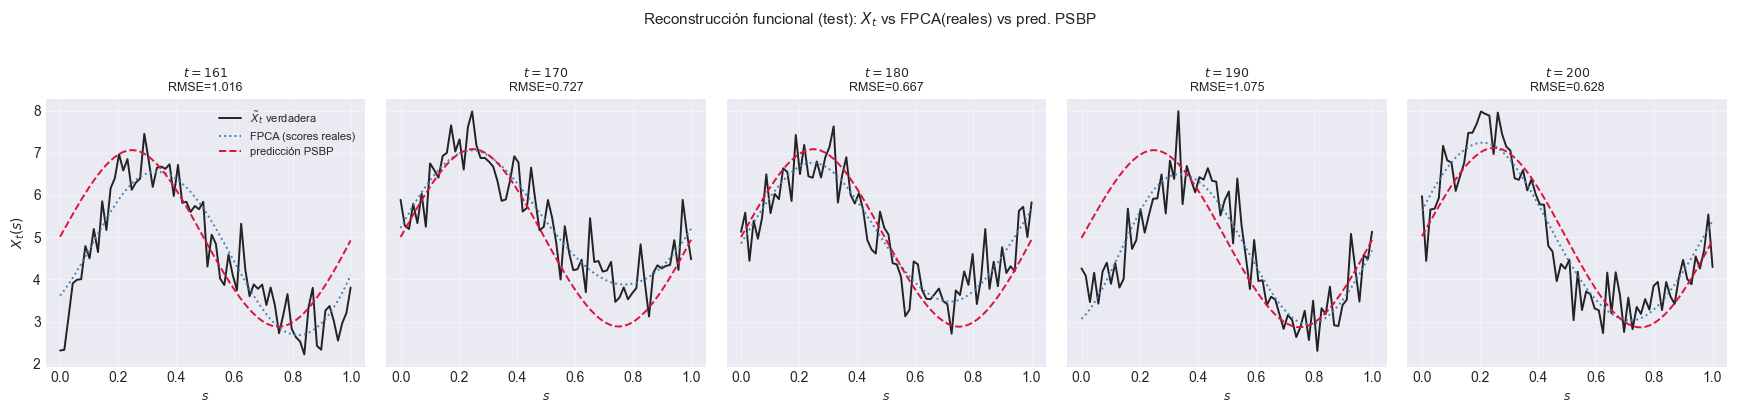

In [15]:
if fpca_available:
    # ── Matriz de scores predichos en escala ESTANDARIZADA (bloque test) ──────
    SCORES_STD_test_obs  = SCORES_STD[T0:, :]                    # (n_test, M)
    SCORES_STD_test_pred = SCORES_STD_test_obs.copy()
    for k, idx in enumerate(COMPONENT_IDX):
        SCORES_STD_test_pred[:, idx] = eval_results[k]["y_hat"]

    # ── Des-estandarizar y reconstruir curvas ─────────────────────────────────
    SCORES_test_obs  = SCORES[T0:, :]                                        # escala original
    SCORES_test_pred = scores_standardizer.inverse_transform(SCORES_STD_test_pred)

    X_test_obs  = X_curves[T0:, :]                               # (n_test, G) observada
    X_fpca_pred = fpca.reconstruct(SCORES_test_pred)            # (n_test, G) vía Ψ
    X_fpca_repr = fpca.reconstruct(SCORES_test_obs)            # repr. FPCA de los reales

    # Ruta B-spline (debe coincidir con la FPCA por B^T W B = I)
    THETA_test_pred = fpca.scores_a_theta(SCORES_test_pred)     # (n_test, K)
    X_bspline_pred  = THETA_test_pred @ Phi.T
    _eq = float(np.abs(X_bspline_pred - X_fpca_pred).max())
    print(f"[sanidad] max|ruta B-spline − ruta FPCA| : {_eq:.2e}  (≈ 0)")
    assert _eq < 1e-8, "Las rutas de reconstrucción divergen."

    # ── Métricas funcionales fuera de muestra (fit) ──────────────────────────
    rmse_repr = rmse_funcional(X_test_obs, X_fpca_repr, domain_grid)
    mise_pred = mise(X_test_obs, X_fpca_pred, domain_grid)
    rmsef_pred = rmse_funcional(X_test_obs, X_fpca_pred, domain_grid)
    print(f"RMSE funcional (truncamiento FPCA) : {rmse_repr:.6f}")
    print(f"MISE predicción (test)             : {mise_pred:.6f}")
    print(f"RMSE funcional predicción (test)   : {rmsef_pred:.6f}")

    # ── Visualización (si COMPONENT_IDX cubre las M componentes en orden) ─────
    if COMPONENT_IDX == list(range(M_fpca)):
        eval_orig = {k: {"y_obs": SCORES_test_obs[:, idx],
                         "y_hat": SCORES_test_pred[:, idx],
                         "incl_named": eval_results[k]["incl_named"]}
                     for k, idx in enumerate(COMPONENT_IDX)}
        fig, metrics = plot_functional_comparison(
            eval_results=eval_orig, fr=fpca, domain_grid=domain_grid,
            X_true=X_curves, n_components=n_components, n_lags=T0,
            n_snapshots=5, repr_label="FPCA (scores reales)",
            title=r"Reconstrucción funcional (test): $X_t$ vs FPCA(reales) vs pred. PSBP",
            save_path=str(PATHS["out_report"] / "21_reconstruccion_funcional_test.png"))
        plt.show()
    else:
        print("⚠ COMPONENT_IDX no cubre las M componentes en orden; se omite el comparativo.")
else:
    print("⚠ FPCA no disponible — omitiendo reconstrucción funcional.")

### 5.4 Serie de tiempo funcional: predicha vs verdadera (bloque de prueba)

Capa B-spline real (`fr`), con la predicción PSBP fuera de muestra alineada al
bloque de prueba (offset $T_0$).

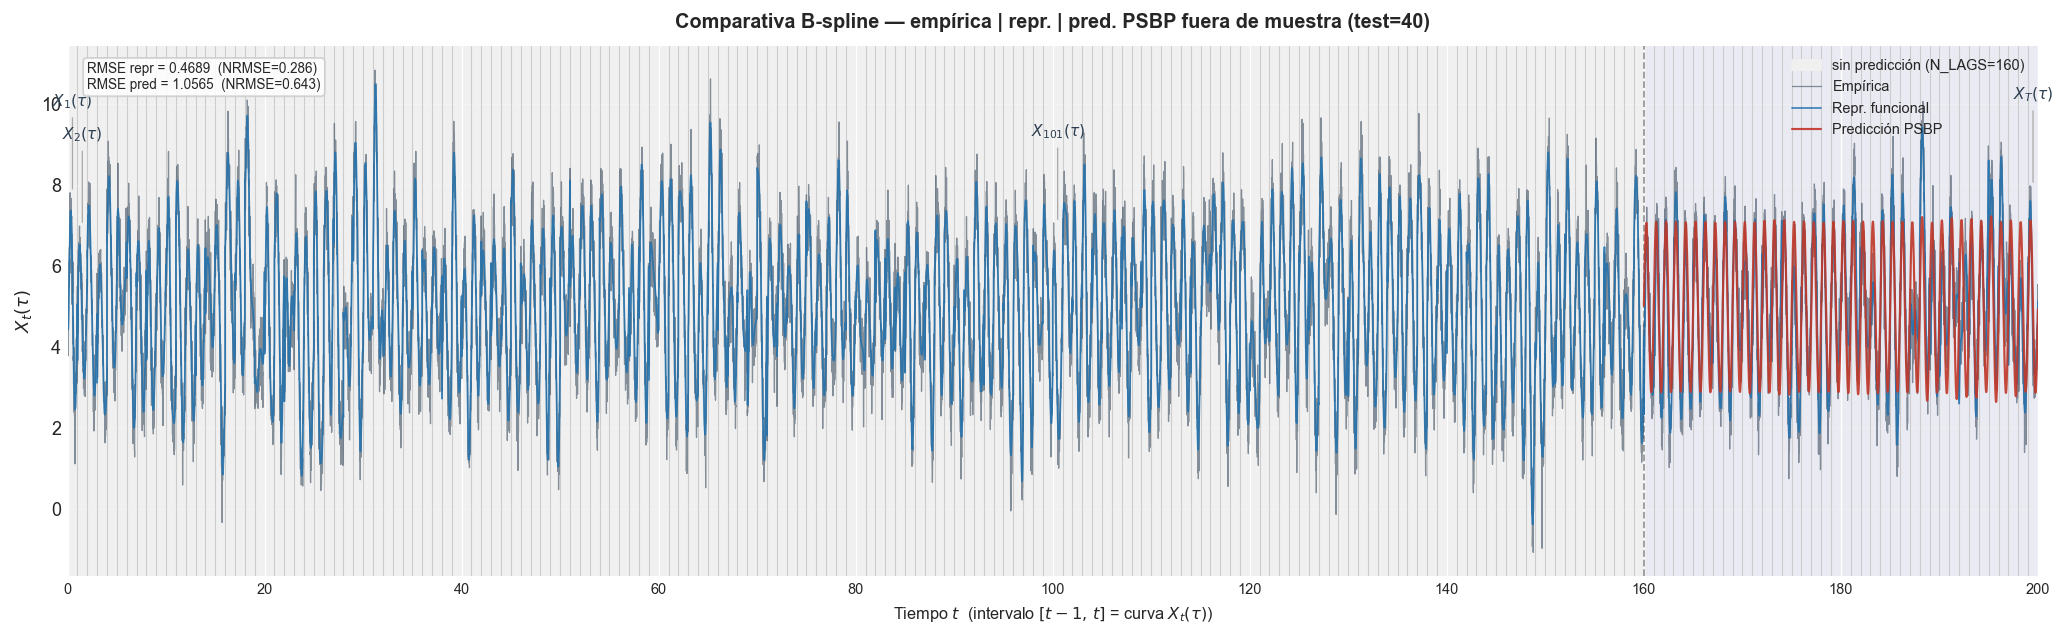

── Métricas B-spline (test) ────────────────────────────────────────
  rmse_repr            : 0.468915
  rmse_pred            : 1.056504
  nrmse_repr           : 0.285556
  nrmse_pred           : 0.643381


In [16]:
if fpca_available and fr is not None:
    fig_bspline, metrics_bspline = plot_fts_comparison(
        X=X_curves, grid=domain_grid, fr=fr,
        X_pred_repr=X_bspline_pred, n_lags=T0,
        title=(f"Comparativa B-spline — empírica | repr. | pred. PSBP fuera de muestra "
               f"(test={n_test_eff})"),
        save_path=str(PATHS["out_report"] / "22_fts_comparacion_bspline.png"))
    plt.show()
    print("── Métricas B-spline (test) ────────────────────────────────────────")
    for key, val in metrics_bspline.items():
        print(f"  {key:20s} : {val:.6f}")
else:
    print("⚠ fr no disponible — omitiendo serie funcional.")

### 5.5 Scatter en espacio de coeficientes B-spline (θ, test)

Vista agrupada (con R² centrado, la cifra honesta de dinámica) y desglose por
coeficiente, que separa el error de truncamiento FPCA del error de modelo.

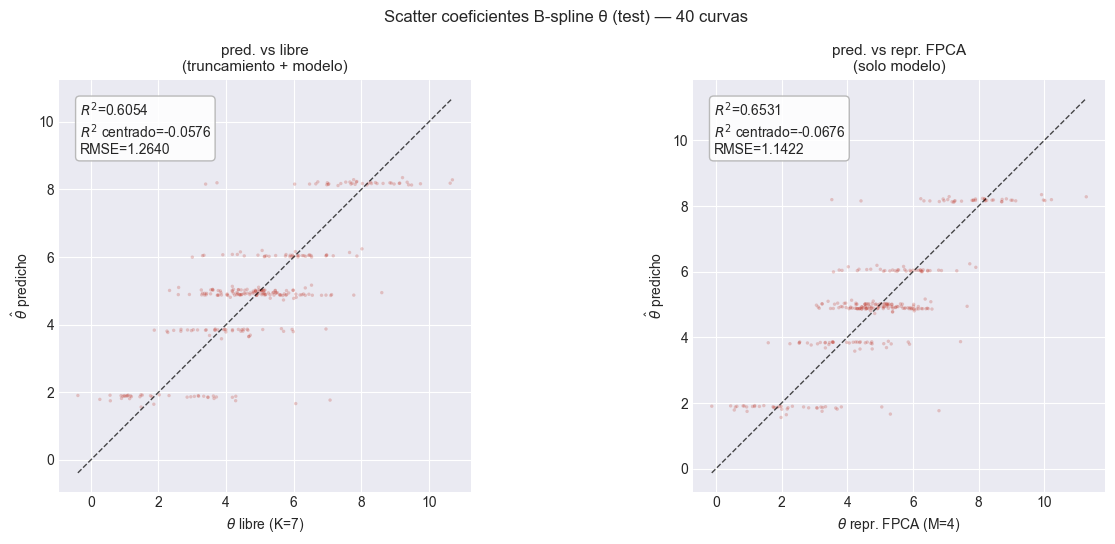

In [17]:
if fpca_available:
    THETA_repr_fpca = fpca.scores_a_theta(SCORES_test_obs)   # (n_test, K) repr. FPCA reales
    THETA_pred      = THETA_test_pred                         # (n_test, K) predicción
    # θ "libre" del bloque test: proyección directa de las curvas observadas
    THETA_free_full = fr.transform(X_curves, domain_grid) if fr is not None else None
    THETA_real_free = THETA_free_full[T0:] if THETA_free_full is not None else THETA_repr_fpca

    def _r2_rmse(x, y):
        x, y = x.ravel(), y.ravel()
        rmse = float(np.sqrt(np.mean((y - x) ** 2)))
        r2   = 1.0 - np.sum((y - x)**2) / np.sum((x - x.mean())**2)
        return r2, rmse
    def _r2c(x, y):  # centrado por columna
        xc, yc = x - x.mean(0), y - x.mean(0)
        return 1.0 - np.sum((yc - xc)**2) / np.sum(xc**2)

    pairs = [
        (THETA_real_free, THETA_pred, rf"$\theta$ libre (K={Phi.shape[1]})",
         "pred. vs libre\n(truncamiento + modelo)"),
        (THETA_repr_fpca, THETA_pred, rf"$\theta$ repr. FPCA (M={M_fpca})",
         "pred. vs repr. FPCA\n(solo modelo)"),
    ]
    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
    for ax, (x, y, xlabel, subtitle) in zip(axes, pairs):
        lo, hi = min(x.min(), y.min()), max(x.max(), y.max())
        ax.plot([lo, hi], [lo, hi], "k--", lw=1, alpha=0.7)
        ax.scatter(x.ravel(), y.ravel(), s=6, alpha=0.25, color="#c0392b", edgecolors="none")
        r2, rmse = _r2_rmse(x, y); r2c = _r2c(x, y)
        ax.set_title(subtitle, fontsize=11)
        ax.set_xlabel(xlabel); ax.set_ylabel(r"$\hat\theta$ predicho")
        ax.text(0.05, 0.95, f"$R^2$={r2:.4f}\n$R^2$ centrado={r2c:.4f}\nRMSE={rmse:.4f}",
                transform=ax.transAxes, va="top",
                bbox=dict(boxstyle="round", fc="white", ec="0.7", alpha=0.9))
        ax.set_aspect("equal", adjustable="box")
    fig.suptitle(rf"Scatter coeficientes B-spline θ (test) — {THETA_pred.shape[0]} curvas",
                 fontsize=12)
    fig.tight_layout()
    fig.savefig(PATHS["out_report"] / "23_scatter_theta_coef.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("⚠ FPCA no disponible.")

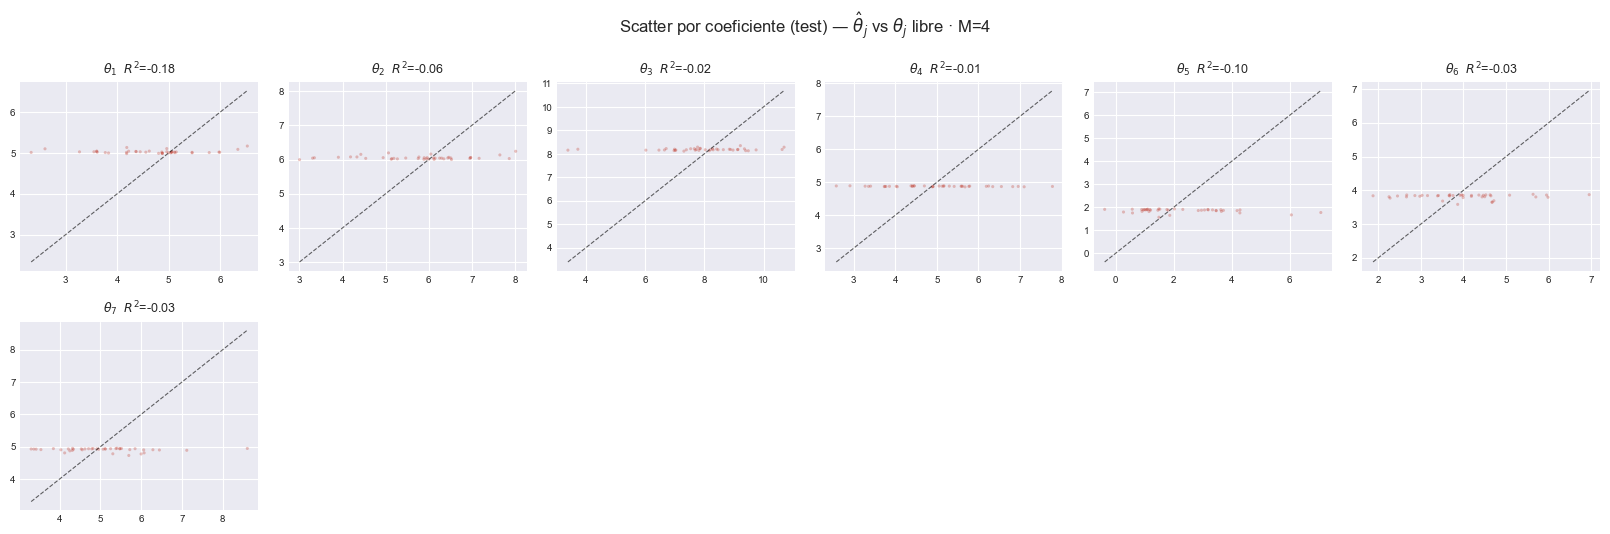

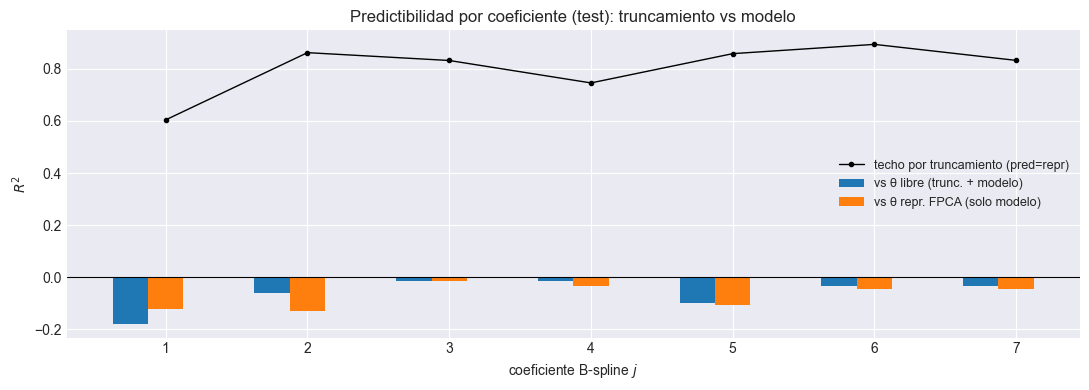

In [18]:
# ── Scatter POR COEFICIENTE B-spline (test) + R² con techo por truncamiento ──
if fpca_available:
    K_b = Phi.shape[1]
    ncol, nrow = 6, int(np.ceil(Phi.shape[1] / 6))
    def _r2(x, y):
        return 1.0 - np.sum((y - x)**2) / np.sum((x - x.mean())**2)

    r2_vs_libre = np.array([_r2(THETA_real_free[:, j], THETA_pred[:, j]) for j in range(K_b)])
    r2_vs_repr  = np.array([_r2(THETA_repr_fpca[:, j], THETA_pred[:, j]) for j in range(K_b)])
    # Techo por truncamiento: R² del mejor modelo posible (pred == repr) vs libre
    r2_techo    = np.array([_r2(THETA_real_free[:, j], THETA_repr_fpca[:, j]) for j in range(K_b)])

    fig, axes = plt.subplots(nrow, ncol, figsize=(2.7*ncol, 2.7*nrow))
    for j, ax in enumerate(np.ravel(axes)):
        if j >= K_b: ax.axis("off"); continue
        x, y = THETA_real_free[:, j], THETA_pred[:, j]
        lo, hi = min(x.min(), y.min()), max(x.max(), y.max())
        ax.plot([lo, hi], [lo, hi], "k--", lw=0.8, alpha=0.6)
        ax.scatter(x, y, s=5, alpha=0.30, color="#c0392b", edgecolors="none")
        ax.set_title(rf"$\theta_{{{j+1}}}$  $R^2$={r2_vs_libre[j]:.2f}", fontsize=9)
        ax.tick_params(labelsize=7)
    fig.suptitle(rf"Scatter por coeficiente (test) — $\hat\theta_j$ vs $\theta_j$ libre · M={M_fpca}",
                 fontsize=12)
    fig.tight_layout()
    fig.savefig(PATHS["out_report"] / "24_scatter_theta_por_coef.png", dpi=150, bbox_inches="tight")
    plt.show()

    fig2, ax2 = plt.subplots(figsize=(11, 4))
    jj = np.arange(1, K_b + 1)
    ax2.bar(jj - 0.25, r2_vs_libre, width=0.25, label="vs θ libre (trunc. + modelo)")
    ax2.bar(jj,        r2_vs_repr,  width=0.25, label="vs θ repr. FPCA (solo modelo)")
    ax2.plot(jj, r2_techo, "k.-", lw=1, ms=6, label="techo por truncamiento (pred=repr)")
    ax2.axhline(0, color="k", lw=0.8)
    ax2.set_xlabel("coeficiente B-spline $j$"); ax2.set_ylabel("$R^2$")
    ax2.set_title("Predictibilidad por coeficiente (test): truncamiento vs modelo")
    ax2.legend(fontsize=9)
    fig2.tight_layout()
    fig2.savefig(PATHS["out_report"] / "25_r2_por_coeficiente.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("⚠ FPCA no disponible.")

### 5.6 Bandas de credibilidad e incertidumbre predictiva (test)

Serie de cada score con banda $\pm1.96\sigma$, curvas con banda funcional
propagada, y diagnósticos de calibración basados en la predictiva muestral
completa: CRPS por score y PIT (§2.2.3.3).

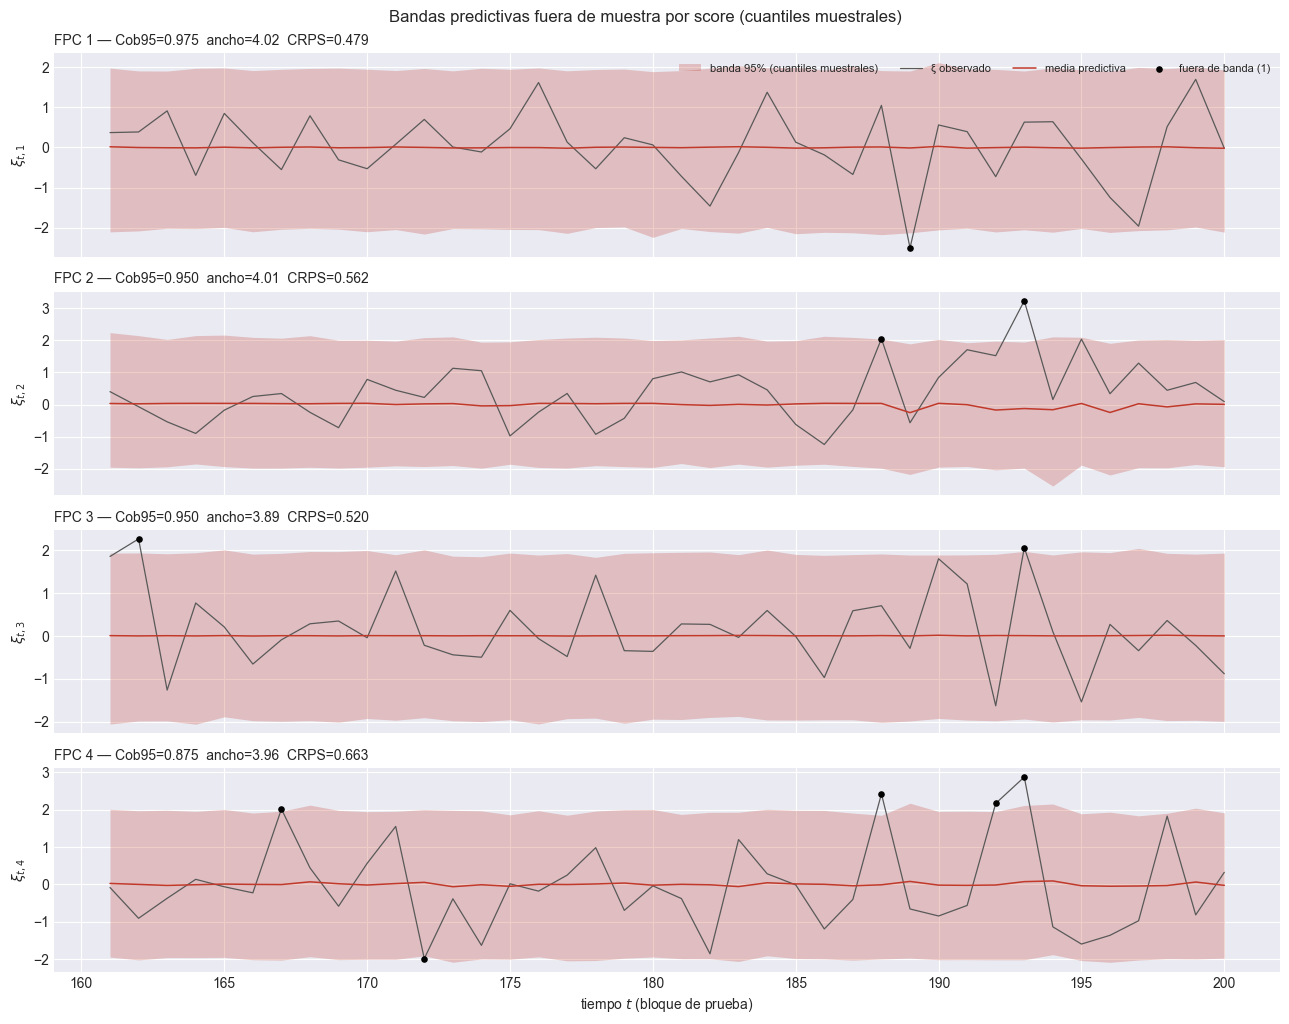

In [19]:
# ── Bandas por score (test): observado vs media ± 1.96σ ─────────────────────
fig, axes = plt.subplots(n_components, 1, figsize=(13, 2.6 * n_components), sharex=True)
axes = np.atleast_1d(axes)
tt_test = np.arange(T0 + 1, T + 1)          # t ∈ {T0+1, …, T}

for k, ax in zip(sorted(models_chains), axes):
    r = eval_results[k]
    # Banda por CUANTILES de la predictiva muestral, no ±1.96σ: la mezcla del
    # PSBPM puede ser asimétrica o multimodal y el intervalo gaussiano la
    # simetriza por construcción.
    ax.fill_between(tt_test, r["li"], r["ls"],
                    alpha=0.25, color="#c0392b", lw=0,
                    label=f"banda {int(NIVEL*100)}% (cuantiles muestrales)")
    ax.plot(tt_test, r["y_obs"], color="0.35", lw=0.9, label="ξ observado")
    ax.plot(tt_test, r["y_hat"], color="#c0392b", lw=1.1, label="media predictiva")
    fuera = (r["y_obs"] < r["li"]) | (r["y_obs"] > r["ls"])
    ax.scatter(tt_test[fuera], r["y_obs"][fuera], s=14, color="k", zorder=3,
               label=f"fuera de banda ({int(fuera.sum())})")
    ax.set_ylabel(rf"$\xi_{{t,{COMPONENT_IDX[k]+1}}}$")
    ax.set_title(f"FPC {COMPONENT_IDX[k]+1} — Cob{int(NIVEL*100)}={r['cov95']:.3f}  "
                 f"ancho={r['ancho95']:.2f}  CRPS={r['crps']:.3f}",
                 fontsize=10, loc="left")
    if k == sorted(models_chains)[0]:
        ax.legend(fontsize=8, ncol=4, loc="upper right")
axes[-1].set_xlabel("tiempo $t$ (bloque de prueba)")
fig.suptitle("Bandas predictivas fuera de muestra por score (cuantiles muestrales)", fontsize=12)
fig.tight_layout()
fig.savefig(PATHS["out_report"] / "26_bandas_scores.png", dpi=150, bbox_inches="tight")
plt.show()

Residuo de representación (train): sd puntual media = 0.5299
Muestras funcionales: (4500, 40, 70)  (S, n_test, G)
sd funcional media  sin residuo = 0.9766
sd funcional media  con residuo = 1.1111   (el truncamiento aporta 12.1%)
Puntaje de energía (test) = 5.9646   (menor es mejor)


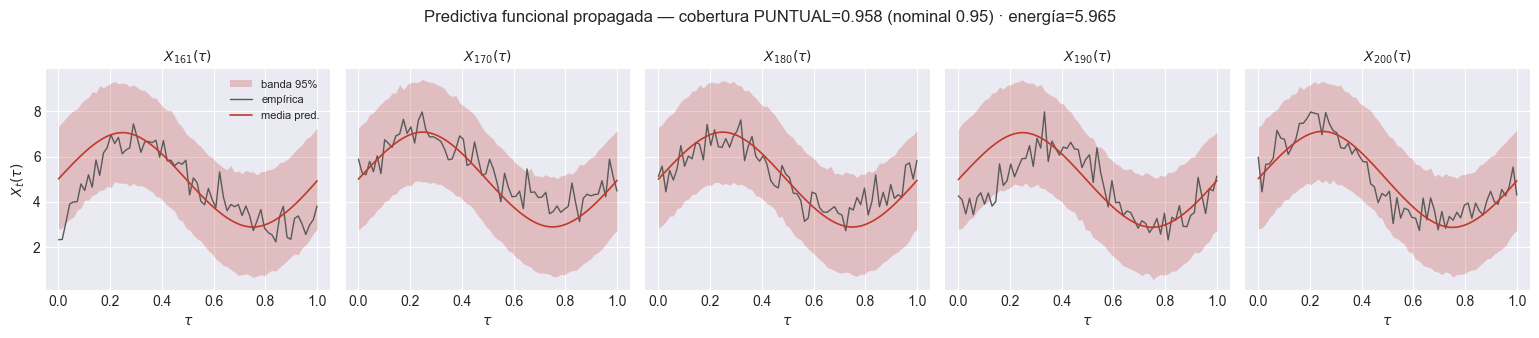


Cobertura puntual (test, nominal 0.95): 0.9579   ← puntual, NO simultánea


In [20]:
# ── Predictiva FUNCIONAL propagada desde los scores ─────────────────────────
# Antes esta celda propagaba sólo dos momentos y construía la banda como
# ±1.96·SD, con SD obtenida de σ² @ (Ψ²)ᵀ. Eso tenía dos problemas: la σ que
# entraba era la del centro y no la predictiva, y la combinación lineal de
# mezclas no es gaussiana, de modo que imponerle simetría destruye justamente
# la forma que el estudio quiere medir.
#
# Ahora se propagan MUESTRAS: se apilan las extracciones de los M scores bajo
# independencia condicional, se des-estandarizan y se reconstruyen las curvas.
#
# Se incorpora además el RESIDUO DE REPRESENTACIÓN. La predictiva reconstruida
# vive en el subespacio de M autofunciones; la curva observada no. Omitirlo
# produce bandas angostas por construcción y una subcobertura que nada tiene
# que ver con el modelo dinámico. Se estima sobre el bloque de ENTRENAMIENTO
# (usarlo del bloque de prueba lo haría depender de lo que se evalúa) y se
# remuestrean curvas residuales completas, lo que preserva su correlación a lo
# largo del dominio, que es marcadamente no blanca.

_cubre_todo = (COMPONENT_IDX == list(range(M_fpca)))

if fpca_available and _cubre_todo:
    # ── Residuo de representación sobre el bloque de entrenamiento ──────────
    X_train_obs = X_curves[:T0, :]
    X_train_rec = fpca.reconstruct(SCORES[:T0, :])
    res_repr    = residuos_representacion(X_train_obs, X_train_rec)
    print(f"Residuo de representación (train): sd puntual media = "
          f"{res_repr.std(axis=0, ddof=1).mean():.4f}")

    propagador = PropagadorFuncional(
        Psi_grid, mu_grid, estandarizador=scores_standardizer,
        residuos=res_repr, modo_residuo="empirico",
    )

    # ── Muestras conjuntas de scores estandarizados: (S, n_test, M) ─────────
    SC_draws = np.stack([eval_results[k]["draws"] for k in range(M_fpca)], axis=2)
    X_draws  = propagador.curvas_desde_scores(SC_draws, seed=SEED_PRED)
    print(f"Muestras funcionales: {X_draws.shape}  (S, n_test, G)")

    # ── Banda puntual y cobertura ──────────────────────────────────────────
    li_f, ls_f = bandas_puntuales(X_draws, nivel=NIVEL)
    X_med_draw = X_draws.mean(axis=0)
    cob_fun    = float(np.mean((X_test_obs >= li_f) & (X_test_obs <= ls_f)))

    # Contribución del truncamiento: sd con y sin residuo de representación
    prop_sin = PropagadorFuncional(Psi_grid, mu_grid,
                                   estandarizador=scores_standardizer,
                                   modo_residuo="ninguno")
    sd_sin = prop_sin.curvas_desde_scores(SC_draws).std(axis=0, ddof=1)
    sd_con = X_draws.std(axis=0, ddof=1)
    print(f"sd funcional media  sin residuo = {sd_sin.mean():.4f}")
    print(f"sd funcional media  con residuo = {sd_con.mean():.4f}   "
          f"(el truncamiento aporta {100*(1-sd_sin.mean()/sd_con.mean()):.1f}%)")

    # ── Puntaje de energía: sensible a la dependencia entre puntos ──────────
    es_fun = energy_score(X_test_obs, X_draws, max_pares=2000, seed=0)
    print(f"Puntaje de energía (test) = {es_fun:.4f}   (menor es mejor)")

    # ── Visualización ──────────────────────────────────────────────────────
    idx_sel = np.linspace(0, X_test_obs.shape[0] - 1, 5).astype(int)
    fig, axes = plt.subplots(1, 5, figsize=(15.5, 3.4), sharey=True)
    for ax, i in zip(axes, idx_sel):
        ax.fill_between(domain_grid, li_f[i], ls_f[i], alpha=0.25,
                        color="#c0392b", lw=0, label=f"banda {int(NIVEL*100)}%")
        ax.plot(domain_grid, X_test_obs[i], color="0.35", lw=1.0, label="empírica")
        ax.plot(domain_grid, X_fpca_pred[i], color="#c0392b", lw=1.2, label="media pred.")
        ax.set_title(rf"$X_{{{T0+1+i}}}(\tau)$", fontsize=10); ax.set_xlabel(r"$\tau$")
    axes[0].set_ylabel(r"$X_t(\tau)$"); axes[0].legend(fontsize=8)
    fig.suptitle(f"Predictiva funcional propagada — cobertura PUNTUAL={cob_fun:.3f} "
                 f"(nominal {NIVEL:.2f}) · energía={es_fun:.3f}", fontsize=12)
    fig.tight_layout()
    fig.savefig(PATHS["out_report"] / "27_banda_funcional_test.png",
                dpi=150, bbox_inches="tight")
    plt.show()

    # La banda es PUNTUAL: la probabilidad de que la curva completa quede
    # contenida en todo el dominio es menor que el nivel nominal. Reportarla
    # como cobertura funcional simultánea exige declararlo.
    print(f"\nCobertura puntual (test, nominal {NIVEL:.2f}): {cob_fun:.4f}   "
          "← puntual, NO simultánea")

elif fpca_available and not _cubre_todo:
    print("⚠ COMPONENT_IDX no cubre las M componentes en orden: la propagación "
          "funcional requiere el vector completo de scores. Se omite.")
else:
    print("⚠ FPCA no disponible — se omite la propagación funcional.")

### 5.7 Métricas resumen fuera de muestra y comparación con líneas base

In [ ]:
# ── Tabla de métricas por componente (test) + comparación con baselines ─────
rows = []
for k in models_chains:
    r = eval_results[k]
    r2  = float(r2_por_columna(r["y_obs"][:, None], r["y_hat"][:, None], centrar=True)[0])
    corr = float(np.corrcoef(r["y_obs"], r["y_hat"])[0, 1])
    rows.append({
        "FPC":         f"FPC {COMPONENT_IDX[k]+1}",
        "RMSE":        r["rmse"],
        "R²":          r2,
        "Corr":        corr,
        "sd(ŷ)/sd(y)": float(razon_dispersion(r["y_obs"][:, None], r["y_hat"][:, None])[0]),
        "CRPS":        r["crps"],
        "Cob95":       r["cov95"],
        "Ancho95":     r["ancho95"],
        "PIT_ks":      float(r["pit_diag"]["ks"]),
        "PIT_forma":   r["pit_diag"]["forma"],
        # Cociente entre la desviación predictiva y la del centro: cuantifica
        # cuánto se estrechaban las bandas bajo el criterio de la v2.
        "sd/sd_centro": float(np.mean(r["y_std"] / np.clip(r["sd_centro"], 1e-12, None))),
        "n_test":      len(r["y_obs"]),
    })
metrics_df = pd.DataFrame(rows).set_index("FPC")
metrics_df.to_csv(PATHS["out_report"] / "31_metricas_por_componente.csv")
print(f"[out_report] 31_metricas_por_componente.csv")

display(metrics_df.style
    .format({"RMSE": "{:.6f}", "R²": "{:.4f}", "Corr": "{:.4f}",
             "sd(ŷ)/sd(y)": "{:.3f}", "CRPS": "{:.4f}", "Cob95": "{:.3f}",
             "Ancho95": "{:.3f}", "PIT_ks": "{:.3f}", "sd/sd_centro": "{:.2f}"})
    .background_gradient(subset=["RMSE"], cmap="RdYlGn_r")
    .background_gradient(subset=["R²"], cmap="RdYlGn", vmin=0, vmax=1)
    .background_gradient(subset=["Cob95"], cmap="RdYlGn", vmin=0.80, vmax=1.0)
    .background_gradient(subset=["CRPS"], cmap="RdYlGn_r")
    .set_caption("Métricas predictivas por componente FPCA (fuera de muestra). "
                 "CRPS y Cob95 provienen de la predictiva MUESTRAL; "
                 "menor CRPS es mejor y Cob95 debe aproximarse al nivel nominal."))

# ── Comparación contra las líneas base del flujo 1 ───────────────────────────
_bl_path = PATHS["out_report"] / "32_baselines_test.csv"
if _bl_path.exists():
    baselines_df = pd.read_csv(_bl_path, index_col=0)
    rmse_psbp = metrics_df["RMSE"].mean()
    print(f"\nRMSE promedio (scores) — PSBP-FD fuera de muestra : {rmse_psbp:.4f}")
    if "RMSE_scores_prom" in baselines_df.columns:
        for modelo, fila in baselines_df.iterrows():
            marca = "✓ PSBP mejor" if rmse_psbp < fila["RMSE_scores_prom"] else "✗ baseline mejor"
            print(f"  vs {modelo:22s} RMSE={fila['RMSE_scores_prom']:.4f}  → {marca}")
else:
    print("\n⚠ No se encontró 32_baselines_test.csv (ejecuta el flujo 1 §6).")